## Setup

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import torch
from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb
from tigramite.independence_tests.gpdc_torch import GPDCtorch
from tigramite.independence_tests.gsquared import Gsquared
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.lpcmci import LPCMCI

from csi_vae_gumbel.settings import Settings

settings = Settings()

IND_TEST = "parcorr"  # "parcorr", "gpdc", "gsquared", "cmisymb", "cmiknn"
DEBUG = False

## Dataset

We use the complete dataset for causal inference, withouy any train/test split.

In [2]:
# Shape will be (T, latent_dim, n_categories)
latents = np.load(f"../{settings.study_path}/latents/latents_hard.npy")

# Shape will be (T,)
labels = np.load(f"../{settings.study_path}/latents/labels.npy")

match IND_TEST:
    case "parcorr" | "gpdc" | "cmiknn":
        # Get the probability of the most likely category for each latent dimension
        latents = torch.softmax(torch.from_numpy(latents), dim=2).numpy()
        latents = np.max(latents, axis=2)
    case "gsquared" | "cmisymb":
        # Get the argmax indices (the most likely category) for each latent dimension
        latents = np.argmax(latents, axis=2)

labelled_causal_data = {}

# 2. Split and THEN shift per activity
for label in np.unique(labels):
    # Extract latents for this specific movement sequence
    activity_latents = latents[labels == label]
    activity_latents = activity_latents[::settings.train_window_size]
    labelled_causal_data[int(label)] = activity_latents

## Causal Analysis

In [3]:
match IND_TEST:
    case "parcorr":
        ind_test = ParCorr(significance="analytic")
    case "gpdc":
        ind_test = GPDCtorch()
    case "gsquared":
        ind_test = Gsquared()
    case "cmisymb":
        ind_test = CMIsymb()
    case "cmiknn":
        ind_test = CMIknn()

Walk


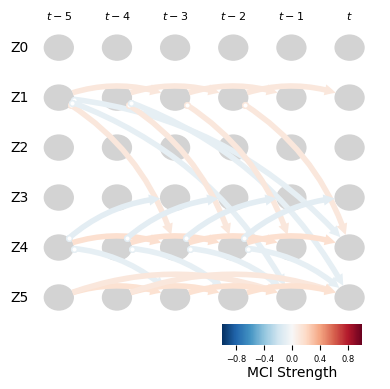

Run


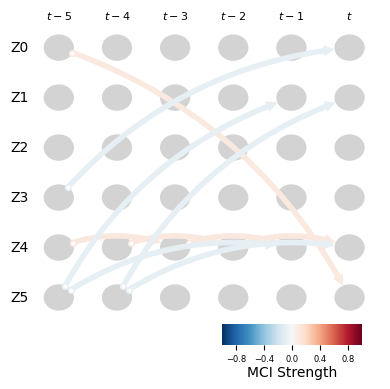

Jump


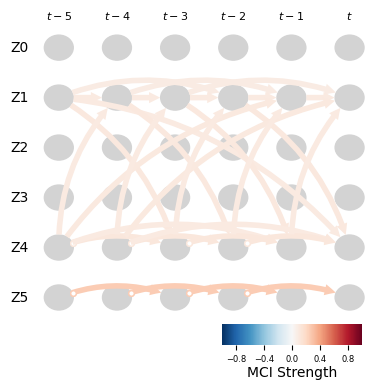

Sit


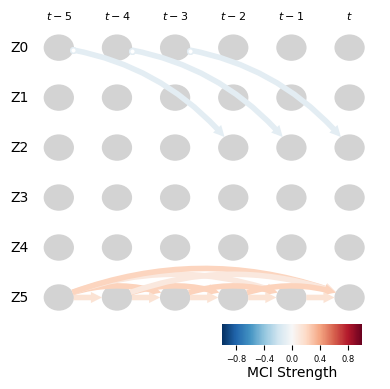

Empty


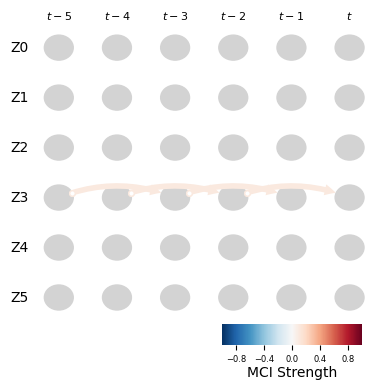

Stand


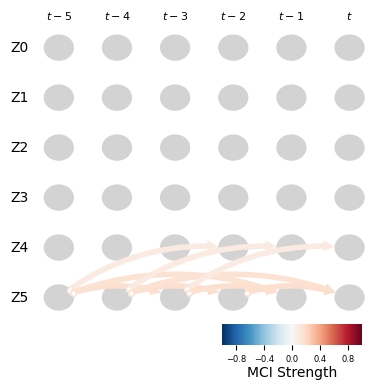

Waving


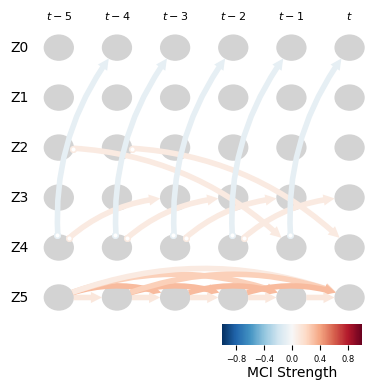

Clap


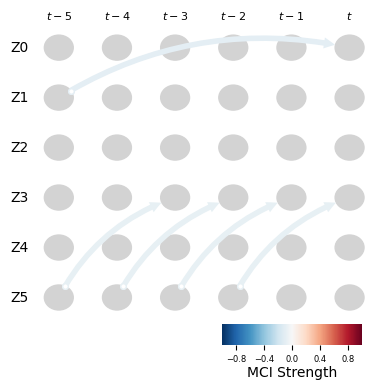

Lay down


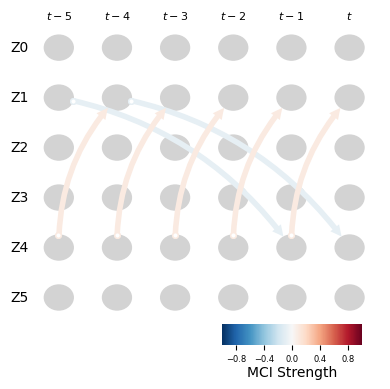

Wipe


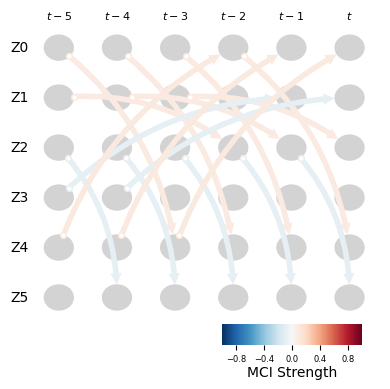

Squat


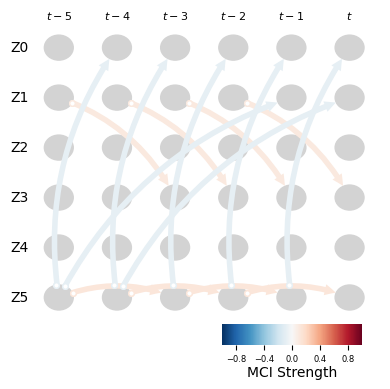

Stretch


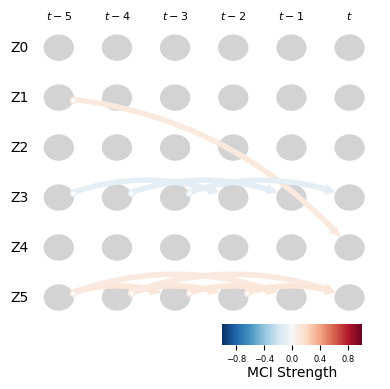

In [4]:
# Correct names: We have 'latent_dim' variables, each taking 'n_categories' values
var_names = [f"Z{i}" for i in range(latents.shape[1])]

tau_min = 1  # minimum time lag
tau_max = settings.test_window_ratio - 1  # maximum time lag

# 2. Iterate through each activity
for label_id, data in labelled_causal_data.items():
    activity_name = settings.activities[label_id]

    # Initialize Tigramite DataFrame
    # Note: 'datatypes' should be 'discrete' for Gsquared
    match IND_TEST:
        case "parcorr" | "gpdc" | "cmiknn":
            dataframe = pp.DataFrame(data, var_names=var_names, data_type=np.zeros_like(data))
        case "gsquared" | "cmisymb":
            dataframe = pp.DataFrame(data, var_names=var_names, data_type=np.ones_like(data))

    # 3. Run LPCMCI
    # LPCMCI is robust to latent common causes (unobserved drivers in CSI)
    lpcmci = LPCMCI(dataframe=dataframe, cond_ind_test=ind_test, verbosity=DEBUG)

    # pc_alpha is the significance level for the conditional independence tests
    results = lpcmci.run_lpcmci(
        tau_min=tau_min,
        tau_max=tau_max,
        pc_alpha=0.01,
    )

    print(activity_name)

    # 4. Plotting
    # Time series graph is best for t, t-1, t-2 visualization
    fig, ax = tp.plot_time_series_graph(
        figsize=(4, 4),
        val_matrix=results["val_matrix"],
        graph=results["graph"],
        var_names=var_names,
        link_colorbar_label="MCI Strength",
    )

    plt.tight_layout()

    plt.show()